In [1]:
import os
import re
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
df = pd.read_csv("tweet_emotions.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (40000, 3)


,tweet_id,sentiment,content
0,1956967341,empty,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,wants to hang out with friends SOON!
4,1956968416,neutral,@dannycastillo We want to trade with someone w...


In [3]:
print(df.columns.tolist())

['tweet_id', 'sentiment', 'content']


In [4]:
print(df.isnull().sum())

tweet_id     0
sentiment    0
content      0
dtype: int64


In [5]:
print(df["sentiment"].value_counts())

sentiment
neutral       8638
worry         8459
happiness     5209
sadness       5165
love          3842
surprise      2187
fun           1776
relief        1526
hate          1323
empty          827
enthusiasm     759
boredom        179
anger          110
Name: count, dtype: int64


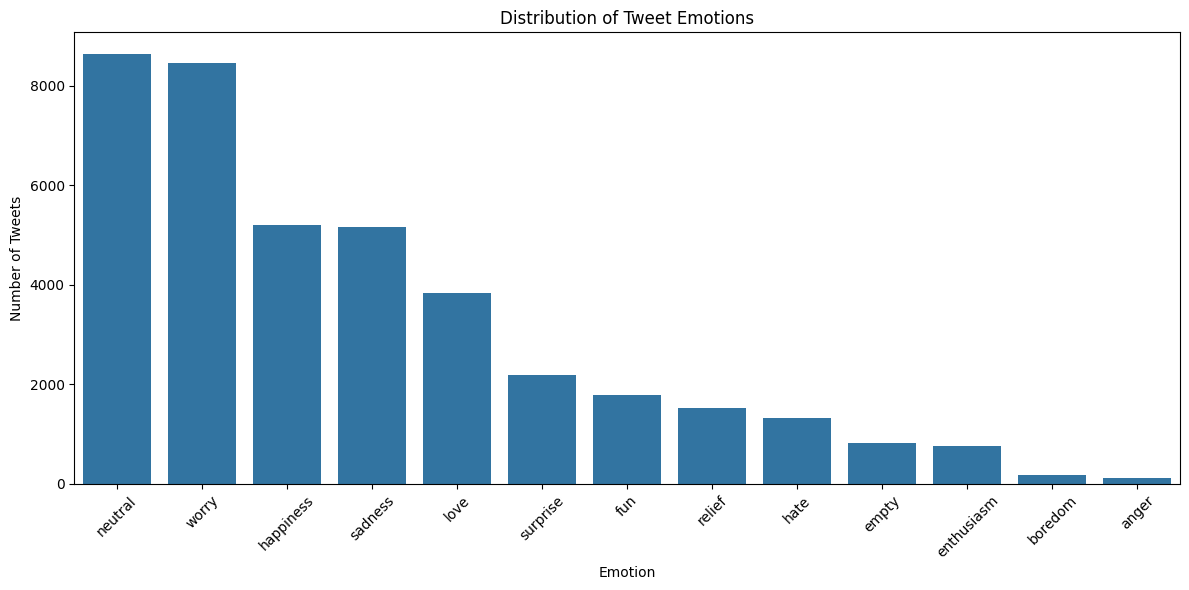

In [6]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="sentiment",
    order=df["sentiment"].value_counts().index
)

plt.title("Distribution of Tweet Emotions")
plt.xlabel("Emotion")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [7]:
for i in range(10):

    print(
        "Emotion:",
        df.iloc[i]["sentiment"]
    )

    print(
        "Tweet:",
        df.iloc[i]["content"]
    )

    print("-" * 80)

Emotion: empty
Tweet: @tiffanylue i know  i was listenin to bad habit earlier and i started freakin at his part =[
--------------------------------------------------------------------------------
Emotion: sadness
Tweet: Layin n bed with a headache  ughhhh...waitin on your call...
--------------------------------------------------------------------------------
Emotion: sadness
Tweet: Funeral ceremony...gloomy friday...
--------------------------------------------------------------------------------
Emotion: enthusiasm
Tweet: wants to hang out with friends SOON!
--------------------------------------------------------------------------------
Emotion: neutral
Tweet: @dannycastillo We want to trade with someone who has Houston tickets, but no one will.
--------------------------------------------------------------------------------
Emotion: worry
Tweet: Re-pinging @ghostridah14: why didn't you go to prom? BC my bf didn't like my friends
-----------------------------------------------------

In [8]:
def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+",
        "",
        text
    )

    # Remove @mentions
    text = re.sub(
        r"@\w+",
        "",
        text
    )

    # Remove HTML
    text = re.sub(
        r"<.*?>",
        "",
        text
    )

    # Keep letters, numbers and spaces
    text = re.sub(
        r"[^a-zA-Z0-9\s]",
        "",
        text
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

In [9]:
df["clean_content"] = df["content"].apply(
    clean_text
)

In [10]:
df[
    ["content", "clean_content"]
].head(10)

,content,clean_content
0,@tiffanylue i know i was listenin to bad habi...,i know i was listenin to bad habit earlier and...
1,Layin n bed with a headache ughhhh...waitin o...,layin n bed with a headache ughhhhwaitin on yo...
2,Funeral ceremony...gloomy friday...,funeral ceremonygloomy friday
3,wants to hang out with friends SOON!,wants to hang out with friends soon
4,@dannycastillo We want to trade with someone w...,we want to trade with someone who has houston ...
5,Re-pinging @ghostridah14: why didn't you go to...,repinging why didnt you go to prom bc my bf di...
6,"I should be sleep, but im not! thinking about ...",i should be sleep but im not thinking about an...
7,Hmmm. http://www.djhero.com/ is down,hmmm is down
8,@charviray Charlene my love. I miss you,charlene my love i miss you
9,@kelcouch I'm sorry at least it's Friday?,im sorry at least its friday


In [11]:
X = df["clean_content"]
y = df["sentiment"]

In [12]:
class_names = sorted(
    y.unique()
)

print("Number of classes:", len(class_names))
print(class_names)

Number of classes: 13
['anger', 'boredom', 'empty', 'enthusiasm', 'fun', 'happiness', 'hate', 'love', 'neutral', 'relief', 'sadness', 'surprise', 'worry']


In [13]:
class_to_index = {
    name: i
    for i, name in enumerate(class_names)
}

index_to_class = {
    i: name
    for name, i in class_to_index.items()
}

y_encoded = y.map(
    class_to_index
).values

In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    stratify=y_encoded,
    random_state=42
)

In [15]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [16]:
print("Training:", len(X_train))
print("Validation:", len(X_val))
print("Testing:", len(X_test))

Training: 28000
Validation: 6000
Testing: 6000


In [17]:
MAX_WORDS = 20000
MAX_LENGTH = 100

vectorizer = layers.TextVectorization(
    max_tokens=MAX_WORDS,
    output_mode="int",
    output_sequence_length=MAX_LENGTH
)

In [18]:
vectorizer.adapt(
    np.array(X_train)
)

In [19]:
vocabulary = vectorizer.get_vocabulary()

print("Vocabulary size:", len(vocabulary))
print(vocabulary[:20])

Vocabulary size: 20000
['', '[UNK]', np.str_('i'), np.str_('to'), np.str_('the'), np.str_('a'), np.str_('my'), np.str_('and'), np.str_('you'), np.str_('it'), np.str_('is'), np.str_('in'), np.str_('for'), np.str_('of'), np.str_('im'), np.str_('on'), np.str_('me'), np.str_('have'), np.str_('so'), np.str_('that')]


In [20]:
sample_text = np.array([
    "I am very happy today"
])

vectorized_text = vectorizer(
    sample_text
)

print(vectorized_text)

tf.Tensor(
[[  2  62 124  50  42   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]], shape=(1, 100), dtype=int64)


In [21]:
layers.Embedding(
    input_dim=MAX_WORDS,
    output_dim=128
)

<Embedding name=embedding, built=False>

In [22]:
def build_simple_rnn():

    model = keras.Sequential([

        layers.Input(
            shape=(1,),
            dtype=tf.string
        ),

        vectorizer,

        layers.Embedding(
            input_dim=MAX_WORDS,
            output_dim=128,
            mask_zero=True
        ),

        layers.SimpleRNN(
            64
        ),

        layers.Dropout(
            0.5
        ),

        layers.Dense(
            64,
            activation="relu"
        ),

        layers.Dense(
            len(class_names),
            activation="softmax"
        )
    ])

    return model

In [23]:
rnn_model = build_simple_rnn()

rnn_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 100)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 100, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 13)             │           845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,577,357 (9.83 MB)

 Trainable params: 2,577,357 (9.83 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

In [25]:
rnn_history = rnn_model.fit(
    np.array(X_train),
    y_train,

    validation_data=(
        np.array(X_val),
        y_val
    ),

    epochs=10,
    batch_size=64,

    callbacks=callbacks
)

Epoch 1/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.2521 - loss: 2.1579 - val_accuracy: 0.2957 - val_loss: 2.0376 - learning_rate: 0.0010
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.3614 - loss: 1.8741 - val_accuracy: 0.3117 - val_loss: 2.0003 - learning_rate: 0.0010
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.5068 - loss: 1.4996 - val_accuracy: 0.2818 - val_loss: 2.2049 - learning_rate: 0.0010
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.6582 - loss: 1.0869 - val_accuracy: 0.2710 - val_loss: 2.4995 - learning_rate: 0.0010
Epoch 5/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.7800 - loss: 0.7123 - val_accuracy: 0.2600 - val_loss: 2.8956 - learning_rate: 5.0000e-04


In [28]:
rnn_loss, rnn_accuracy = rnn_model.evaluate(
    np.array(X_test),
    y_test
)

print("RNN Test Loss:", rnn_loss)
print("RNN Test Accuracy:", rnn_accuracy)

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3155 - loss: 1.9906
RNN Test Loss: 1.990567922592163
RNN Test Accuracy: 0.3154999911785126


In [29]:
rnn_probabilities = rnn_model.predict(
    np.array(X_test)
)

rnn_predictions = np.argmax(
    rnn_probabilities,
    axis=1
)

188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step


In [30]:
print(
    classification_report(
        y_test,
        rnn_predictions,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       anger       0.00      0.00      0.00        16
     boredom       0.00      0.00      0.00        27
       empty       0.00      0.00      0.00       124
  enthusiasm       0.00      0.00      0.00       114
         fun       0.00      0.00      0.00       266
   happiness       0.29      0.34      0.31       782
        hate       0.30      0.02      0.03       199
        love       0.40      0.35      0.37       576
     neutral       0.33      0.54      0.41      1296
      relief       0.00      0.00      0.00       229
     sadness       0.23      0.13      0.17       774
    surprise       0.00      0.00      0.00       328
       worry       0.31      0.49      0.38      1269

    accuracy                           0.32      6000
   macro avg       0.14      0.14      0.13      6000
weighted avg       0.25      0.32      0.27      6000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


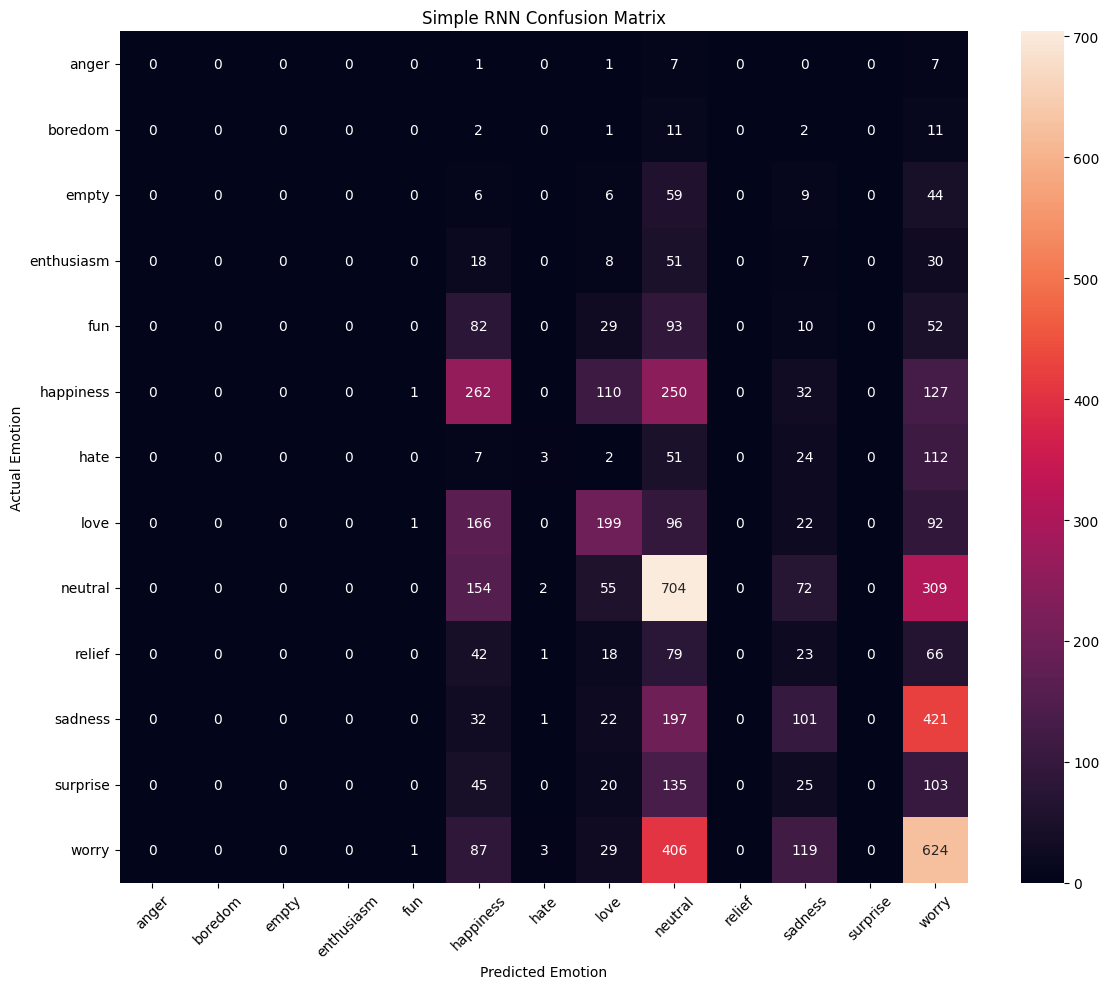

In [31]:
cm = confusion_matrix(
    y_test,
    rnn_predictions
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Simple RNN Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [32]:
def build_bidirectional_rnn():

    model = keras.Sequential([

        layers.Input(
            shape=(1,),
            dtype=tf.string
        ),

        vectorizer,

        layers.Embedding(
            input_dim=MAX_WORDS,
            output_dim=128,
            mask_zero=True
        ),

        layers.Bidirectional(
            layers.SimpleRNN(64)
        ),

        layers.Dropout(
            0.5
        ),

        layers.Dense(
            64,
            activation="relu"
        ),

        layers.Dense(
            len(class_names),
            activation="softmax"
        )
    ])

    return model

In [33]:
bi_rnn_model = build_bidirectional_rnn()

bi_rnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [34]:
bi_rnn_history = bi_rnn_model.fit(
    np.array(X_train),
    y_train,

    validation_data=(
        np.array(X_val),
        y_val
    ),

    epochs=10,
    batch_size=64,

    callbacks=callbacks
)

Epoch 1/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 49s 100ms/step - accuracy: 0.2692 - loss: 2.1125 - val_accuracy: 0.3095 - val_loss: 1.9877 - learning_rate: 0.0010
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 73s 80ms/step - accuracy: 0.3943 - loss: 1.7823 - val_accuracy: 0.3143 - val_loss: 1.9829 - learning_rate: 0.0010
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 36s 82ms/step - accuracy: 0.5685 - loss: 1.3233 - val_accuracy: 0.2933 - val_loss: 2.2593 - learning_rate: 0.0010
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 41s 81ms/step - accuracy: 0.7339 - loss: 0.8528 - val_accuracy: 0.2710 - val_loss: 2.6182 - learning_rate: 0.0010
Epoch 5/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - accuracy: 0.8509 - loss: 0.4926 - val_accuracy: 0.2617 - val_loss: 3.0651 - learning_rate: 5.0000e-04


LSTM

In [35]:
def build_lstm():

    model = keras.Sequential([

        layers.Input(
            shape=(1,),
            dtype=tf.string
        ),

        vectorizer,

        layers.Embedding(
            input_dim=MAX_WORDS,
            output_dim=128,
            mask_zero=True
        ),

        layers.LSTM(
            64
        ),

        layers.Dropout(
            0.5
        ),

        layers.Dense(
            64,
            activation="relu"
        ),

        layers.Dense(
            len(class_names),
            activation="softmax"
        )
    ])

    return model

In [36]:
lstm_model = build_lstm()

lstm_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [37]:
lstm_history = lstm_model.fit(
    np.array(X_train),
    y_train,

    validation_data=(
        np.array(X_val),
        y_val
    ),

    epochs=10,
    batch_size=64,

    callbacks=callbacks
)

Epoch 1/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 50s 104ms/step - accuracy: 0.2670 - loss: 2.1334 - val_accuracy: 0.3275 - val_loss: 1.9655 - learning_rate: 0.0010
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 46s 105ms/step - accuracy: 0.3764 - loss: 1.8421 - val_accuracy: 0.3363 - val_loss: 1.9634 - learning_rate: 0.0010
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 46s 104ms/step - accuracy: 0.4612 - loss: 1.6135 - val_accuracy: 0.3238 - val_loss: 2.0567 - learning_rate: 0.0010
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 82s 104ms/step - accuracy: 0.5436 - loss: 1.3944 - val_accuracy: 0.3087 - val_loss: 2.2073 - learning_rate: 0.0010
Epoch 5/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 47s 106ms/step - accuracy: 0.6478 - loss: 1.1207 - val_accuracy: 0.2927 - val_loss: 2.4553 - learning_rate: 5.0000e-04


GRU

In [38]:
def build_gru():

    model = keras.Sequential([

        layers.Input(
            shape=(1,),
            dtype=tf.string
        ),

        vectorizer,

        layers.Embedding(
            input_dim=MAX_WORDS,
            output_dim=128,
            mask_zero=True
        ),

        layers.GRU(
            64
        ),

        layers.Dropout(
            0.5
        ),

        layers.Dense(
            64,
            activation="relu"
        ),

        layers.Dense(
            len(class_names),
            activation="softmax"
        )
    ])

    return model

In [39]:
gru_model = build_gru()

gru_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [40]:
gru_history = gru_model.fit(
    np.array(X_train),
    y_train,

    validation_data=(
        np.array(X_val),
        y_val
    ),

    epochs=10,
    batch_size=64,

    callbacks=callbacks
)

Epoch 1/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 53s 114ms/step - accuracy: 0.2731 - loss: 2.1011 - val_accuracy: 0.3298 - val_loss: 1.9664 - learning_rate: 0.0010
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 51s 117ms/step - accuracy: 0.3770 - loss: 1.8338 - val_accuracy: 0.3360 - val_loss: 1.9619 - learning_rate: 0.0010
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 82s 116ms/step - accuracy: 0.4694 - loss: 1.5992 - val_accuracy: 0.3250 - val_loss: 2.0643 - learning_rate: 0.0010
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 78s 107ms/step - accuracy: 0.5575 - loss: 1.3554 - val_accuracy: 0.2992 - val_loss: 2.2426 - learning_rate: 0.0010
Epoch 5/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 48s 111ms/step - accuracy: 0.6634 - loss: 1.0538 - val_accuracy: 0.2917 - val_loss: 2.5475 - learning_rate: 5.0000e-04


In [42]:
models = {
    "Simple RNN": rnn_model,
    "Bidirectional RNN": bi_rnn_model,
    "LSTM": lstm_model,
    "LSTM": lstm_model,
    "GRU": gru_model
}

In [43]:
results = []

for name, model in models.items():

    loss, accuracy = model.evaluate(
        np.array(X_test),
        y_test,
        verbose=0
    )

    results.append({
        "Model": name,
        "Test Loss": loss,
        "Test Accuracy": accuracy
    })

results_df = pd.DataFrame(results)

results_df

,Model,Test Loss,Test Accuracy
0,Simple RNN,1.990568,0.315500
1,Bidirectional RNN,1.968678,0.324167
2,LSTM,1.940016,0.346000
3,GRU,1.945551,0.338667


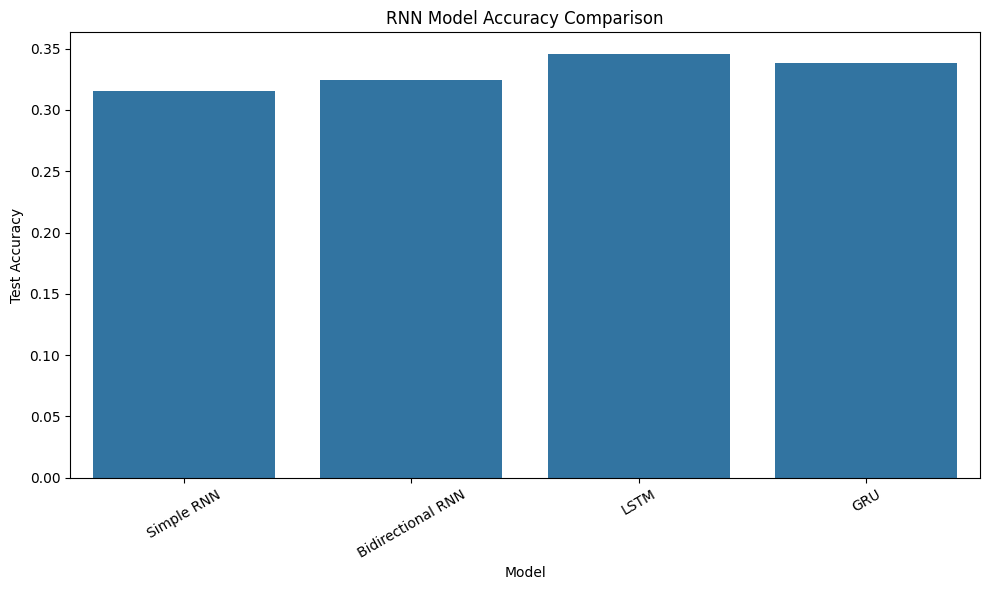

In [44]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Test Accuracy"
)

plt.title(
    "RNN Model Accuracy Comparison"
)

plt.ylabel("Test Accuracy")
plt.xlabel("Model")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

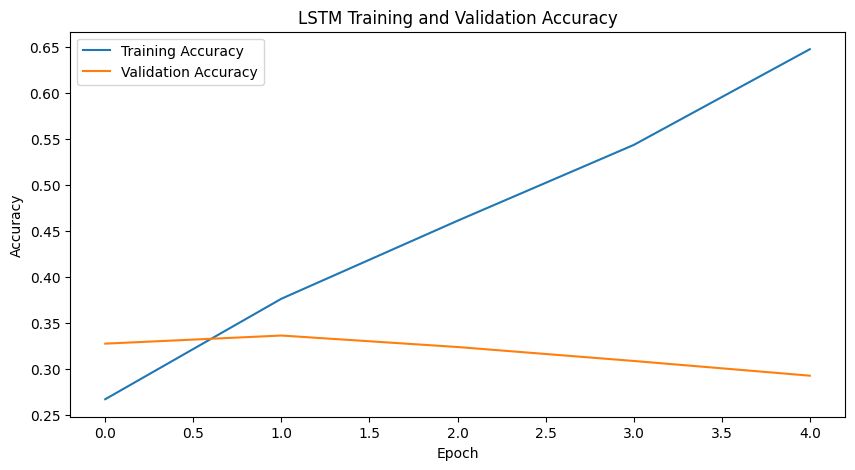

In [45]:
plt.figure(figsize=(10, 5))

plt.plot(
    lstm_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    lstm_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("LSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

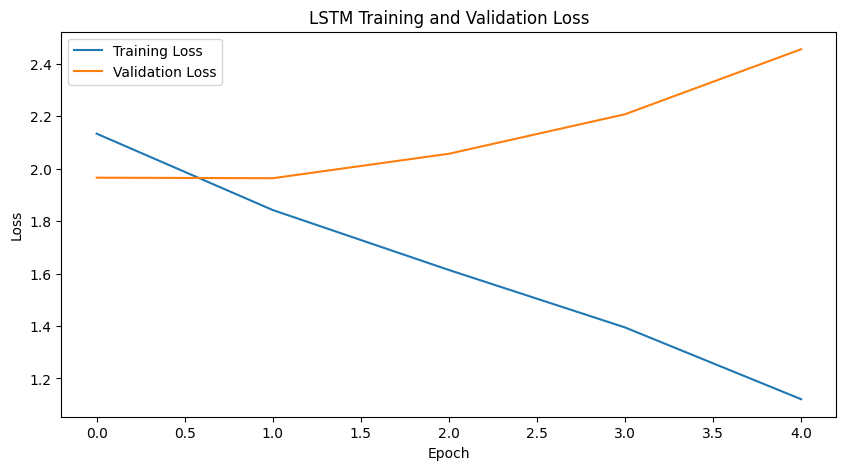

In [46]:
plt.figure(figsize=(10, 5))

plt.plot(
    lstm_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [47]:
final_model = lstm_model

In [48]:
final_probabilities = final_model.predict(
    np.array(X_test)
)

final_predictions = np.argmax(
    final_probabilities,
    axis=1
)

188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step


In [49]:
final_report = classification_report(
    y_test,
    final_predictions,
    target_names=class_names
)

print(final_report)

              precision    recall  f1-score   support

       anger       0.00      0.00      0.00        16
     boredom       0.00      0.00      0.00        27
       empty       0.00      0.00      0.00       124
  enthusiasm       0.00      0.00      0.00       114
         fun       0.50      0.01      0.01       266
   happiness       0.33      0.32      0.33       782
        hate       0.41      0.20      0.26       199
        love       0.51      0.41      0.45       576
     neutral       0.32      0.66      0.43      1296
      relief       0.00      0.00      0.00       229
     sadness       0.46      0.05      0.09       774
    surprise       0.00      0.00      0.00       328
       worry       0.33      0.52      0.41      1269

    accuracy                           0.35      6000
   macro avg       0.22      0.17      0.15      6000
weighted avg       0.33      0.35      0.29      6000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


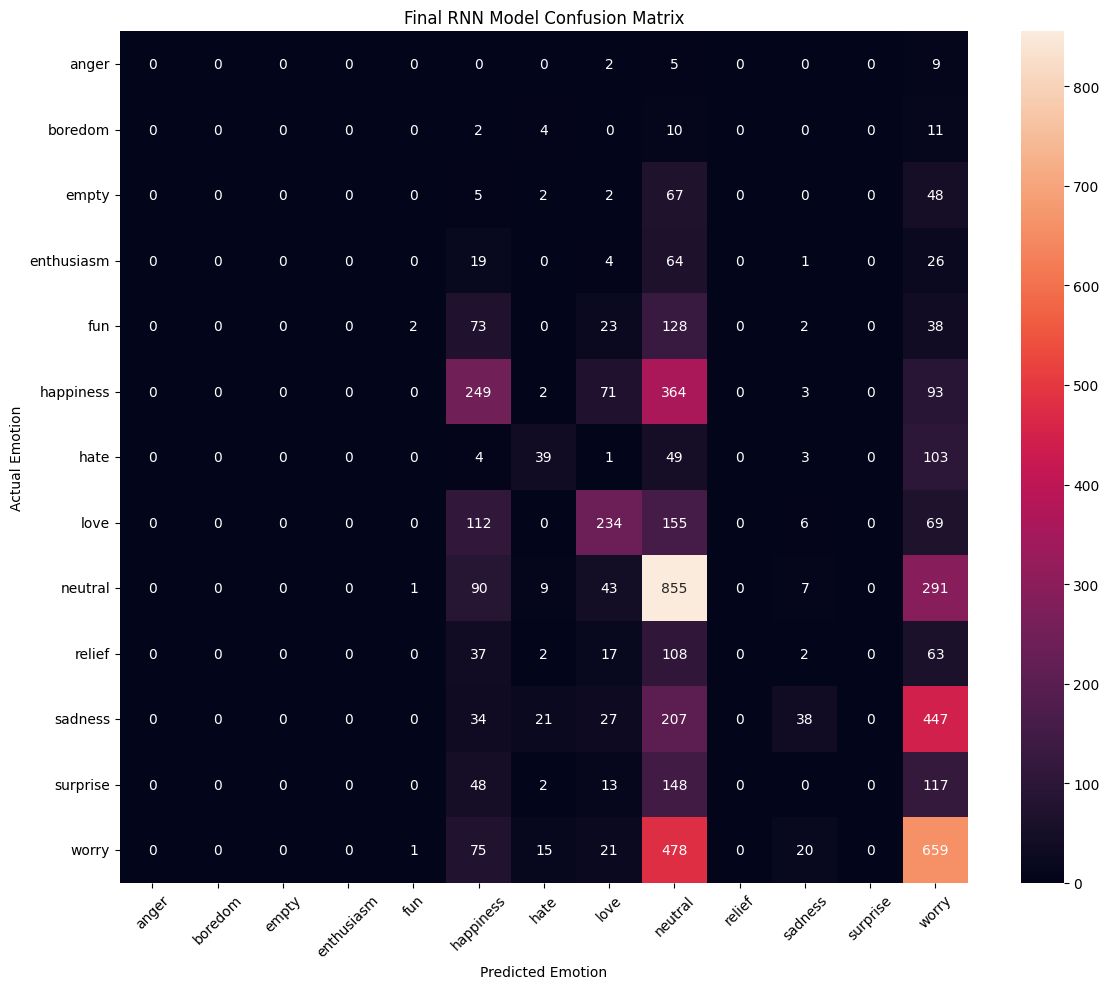

In [50]:
final_cm = confusion_matrix(
    y_test,
    final_predictions
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Final RNN Model Confusion Matrix"
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [55]:
def predict_top3(
    text,
    model=final_model
):

    probabilities = model.predict(
        np.array([text]),
        verbose=0
    )[0]

    top_indices = np.argsort(
        probabilities
    )[::-1][:3]

    print("Tweet:", text)
    print("\nTop predictions:")

    for index in top_indices:

        print(
            f"{index_to_class[index]}: "
            f"{probabilities[index] * 100:.2f}%"
        )